# Compound clustering

## Aim
Similar compounds might bind to the same targets and show similar effects. Based on this similar property principle, compound similarity can be used to build chemical groups via clustering. From such a clustering, a diverse set of compounds can also be selected from a larger set of screening compounds for further experimental testing.

## For more details
https://github.com/volkamerlab/teachopencadd/blob/master/teachopencadd/talktorials/T005_compound_clustering/talktorial.ipynb

## Instructions
Replace XXX with the appropriate code

## Configuration

In [1]:
# Magic commands
%load_ext autoreload
%autoreload 2

In [2]:
# Imports
# 1. Standard library imports
from pathlib import Path
import pickle
import sys
sys.path.append('../my_modules') # to tell where to find local modules

# 2. Third-party library imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import random
from rdkit import Chem, DataStructs
from rdkit.Chem import (
    Draw,
    PandasTools,
    rdFingerprintGenerator,
)
from rdkit.ML.Cluster import Butina
PandasTools.RenderImagesInAllDataFrames(images=True) # to molecules as images in DataFrames
from rdkit.Chem.Draw import IPythonConsole # needed to show molecules
# from rdkit.Chem.Draw.MolDrawing import MolDrawing, DrawingOptions # only needed if modifying defaults

import seaborn as sns

# 3. Local application imports
import kernel_infos

In [3]:
# Information about the kernel
kernel_infos.show_kernel_info()

=== Kernel Information ===
Python version: 3.14.0 (main, Oct  7 2025, 09:34:52) [Clang 17.0.0 (clang-1700.0.13.3)]
Executable: /Users/bourg/Enseignement/GSON/gson_sbc/.venv/bin/python
Platform: macOS-26.2-arm64-arm-64bit-Mach-O
IPython version: 9.7.0


In [4]:
# Global variables
HERE = Path().resolve()
print(f'{HERE}')
ROOT = HERE.parent
print(f'{ROOT}')
DATA = ROOT / 'data'
print(f'{DATA}')

/Users/bourg/Enseignement/GSON/gson_sbc/notebooks
/Users/bourg/Enseignement/GSON/gson_sbc
/Users/bourg/Enseignement/GSON/gson_sbc/data


## Data

In [5]:
# File to load
EGFR_compounds_lipinski_csv_path = DATA / "EGFR_compounds_lipinski.csv"

In [6]:
# Load data in a dataframe called egfr_df
egfr_df = pd.read_csv(EGFR_compounds_lipinski_csv_path, index_col=0)

In [7]:
# Check
print(f"egfr_df shape: {egfr_df.shape}")
egfr_df.head(2)

egfr_df shape: (7153, 10)


,molecule_chembl_id,IC50,units,smiles,pIC50,MW,HBA,HBD,LogP,ro5_fulfilled
0,CHEMBL63786,0.003,nM,Brc1cccc(Nc2ncnc3cc4ccccc4cc23)c1,11.522879,349.021459,3,1,5.2891,True
1,CHEMBL35820,0.006,nM,CCOc1cc2ncnc(Nc3cccc(Br)c3)c2cc1OCC,11.221849,387.058239,5,1,4.9333,True


In [8]:
# Create a list coumpounds_l of tuples (RDKit molecule, molecule_chembl_id)

# Initialise compounds_l
compounds_l = list()

# Iterate over the dataframe egfr_df with itertuples() - return a tuple (index, col1, col2, ...)
for _, chembl_id, smiles in egfr_df[['molecule_chembl_id', 'smiles']].itertuples():
    compounds_l.append((Chem.MolFromSmiles(smiles), chembl_id))

# List the 5 first elements of compounds_l
compounds_l[:5]

[(<rdkit.Chem.rdchem.Mol at 0x11dcd6dc0>, 'CHEMBL63786'),
 (<rdkit.Chem.rdchem.Mol at 0x11dcd6ce0>, 'CHEMBL35820'),
 (<rdkit.Chem.rdchem.Mol at 0x11dcd6c70>, 'CHEMBL53711'),
 (<rdkit.Chem.rdchem.Mol at 0x11dcd6c00>, 'CHEMBL53753'),
 (<rdkit.Chem.rdchem.Mol at 0x11dcd6b90>, 'CHEMBL66031')]

## Calculate fingerprints

In [9]:
# Create RDKit fingerprints for all molecules
rdkit_gen = rdFingerprintGenerator.GetRDKitFPGenerator(maxPath=5)
rdkit_fps_l = [rdkit_gen.GetFingerprint(mol) for mol, idx in compounds_l]

# How many compounds/fingerprints do we have?
print("Number of compounds converted:", len(rdkit_fps_l))
# What is the lengh of a fingerprint ?
print("Fingerprint length per compound:", len(rdkit_fps_l[0]))

Number of compounds converted: 7153
Fingerprint length per compound: 2048


## Tanimoto similarity and distance matrix

In [10]:
# Caculate Tanimoto similarity of first two fingerprints 
Tc_sim = DataStructs.TanimotoSimilarity(rdkit_fps_l[0], rdkit_fps_l[1])

# Print Tanimoto similarity and distance
print(f"Tanimoto similarity: {Tc_sim:.2f}\nDistance: {1-Tc_sim:.2f}")

Tanimoto similarity: 0.73
Distance: 0.27


In [11]:
# Define a function to calculate a tanimoto distance matrix, implemented as a list, from a list of fingerprints
def tanimoto_distance_matrix(fps_l):
     """Calculate distance matrix for fingerprint list"""
     # initialise a list
     dist_matrix = []
     # in a loop from 1 to len(fps_l) for i given
     for i in range(1, len(fps_l)):
          # calculate tanimoto similarity between fp_i and fps_list of index 1 to i excluded
          similarities = DataStructs.BulkTanimotoSimilarity(fps_l[i], fps_l[:i])
          # add distances (1 - Tanimoto) to the distance matrix
          dist_matrix.extend([1 - Tc for Tc in similarities])
     # Return dist_matrix
     return dist_matrix

In [12]:
# Calculate matrix
distance_matrix_egfr = tanimoto_distance_matrix(rdkit_fps_l)

In [13]:
# Print the first five values
for elt in distance_matrix_egfr[0:5]:
    print(f"{elt:.5f}")

0.26996
0.26538
0.40867
0.22672
0.38387


In [14]:
# Calculate the number of element of the matrix
n_fps = len(rdkit_fps_l)
print(f"Number of fingerprints: {n_fps}")

# n elts in matrix
print(f"Number of distances, read: {len(distance_matrix_egfr)}")

# calculate the number of elements in the triangular matrix = sum (1, 2, 3, ..., n_fps-1) 
print(f"Number of distances, computed: {int((n_fps-1) * (n_fps) / 2)}")

Number of fingerprints: 7153
Number of distances, read: 25579128
Number of distances, computed: 25579128


## Clustering

In [15]:
# Define a clustering function
def cluster_fps(fps_l, cutoff=0.2):
    # calculate Tanimoto distance matrix
    distance_matrix = tanimoto_distance_matrix(fps_l)
    # cluster data with Butina algorithm
    clusters = Butina.ClusterData(
        distance_matrix, 
        len(fps_l),
        cutoff,
        isDistData=True)
    return clusters

In [16]:
# Cluster egfr dataset with a distance threshold of 0.3
dist_threshold = 0.3
clusters = cluster_fps(
    fps_l=rdkit_fps_l,
    cutoff=dist_threshold)

In [17]:
# Clusters file
cluster_pkl_path = DATA / "cluster0.3.pkl"

# Save clusters
with open(cluster_pkl_path, 'wb') as f:
    pickle.dump(clusters, f)

In [18]:
# # Load clusters
# with open(cluster_pkl_path, 'rb') as f:
#     clusters = pickle.load(f)

In [19]:
# What is the type of clusters ?
print(f'Type of clusters: {type(clusters)}')

# How many clusters ?
print(f"Number of clusters: '{len(clusters)}")

# What is the type of a cluster, ex with the first cluster ?
print(f'Type of a cluster: {type(clusters[0])}')

# Define c3_l, a list of all clusters with length of 3
c3_l = [clust for clust in clusters if len(clust) == 3]

# Print size of c3_l
print(f"Size of c3_l: {len(c3_l)}")

# Print the first cluster of c3_l
print(f"First cluster: {c3_l[0]}")

Type of clusters: <class 'tuple'>
Number of clusters: '1157
Type of a cluster: <class 'tuple'>
Size of c3_l: 78
First cluster: (4392, 4390, 4391)


In [20]:
# Fix distance threshold to 1
dist_threshold = 1.0

# Cluster egfr dataset
clusters = cluster_fps(rdkit_fps_l, cutoff=dist_threshold)

# Clusters file
cluster_pkl_path = DATA / "cluster1.0.pkl"
# Save clusters
with open(cluster_pkl_path, 'wb') as f:
    pickle.dump(clusters, f)
# # Load clusters
# with open(cluster_pkl_path, 'rb') as f:
#     clusters = pickle.load(f)

# How many clusters ?
print(f"Number of clusters : {len(clusters)}")

# How many compounds in the first cluster ?
print(f"Number of compounds in cluster #0 : {len(clusters[0])}")

Number of clusters : 1
Number of compounds in cluster #0 : 7153


**What conclusions can be drawn for a dist_threshold of 1 ?**  
A dist_threshold of 1.0 clusters all molecules into a single cluster. The compounds are all considered identical, even if they are not.

In [21]:
# Fix distance threshold to 0
dist_threshold = 0.0

# Cluster egfr dataset
clusters = cluster_fps(rdkit_fps_l, cutoff=dist_threshold)

# Clusters file
cluster_pkl_path = DATA / "cluster0.0.pkl"
# Save clusters
with open(cluster_pkl_path, 'wb') as f:
    pickle.dump(clusters, f)
# # Load clusters
# with open(cluster_pkl_path, 'rb') as f:
#     clusters = pickle.load(f)

# How many clusters ?
print(f"Number of clusters : {len(clusters)}")

# How many compounds in ten randomly selected clusters ?
for c in random.sample(clusters,10):
    print(f"{len(c)}")

Number of clusters : 6777
1
1
1
1
1
1
1
1
1
2


**What conclusions can be drawn for a dist_threshold of 0 ?**  
With a distance threshold of 0, the compounds are considered to be all different, unless they are truly identical. So we obtain almost one cluster per compound.

## How to pick a reasonable cutoff ?

In [22]:
# Define a function to plot the size of clusters
def plot_cluster_sizes(clusters, cutoff):
    plt.figure(1, figsize=(10, 4))
    plt1 = plt.subplot(111)
    plt.axis([0, len(clusters), 0, len(clusters[0])+1])
    plt.xlabel('Cluster index', fontsize=16)
    plt.ylabel('Number of molecules', fontsize=16)
    plt.title(f'Distance threshold: {cutoff:.2f}')
    plt.tick_params(labelsize=16)
    plt1.bar(
        range(1, len(clusters)), 
        [len(c) for c in clusters[:len(clusters)-1]],
        lw=0
    )
    plt.show()

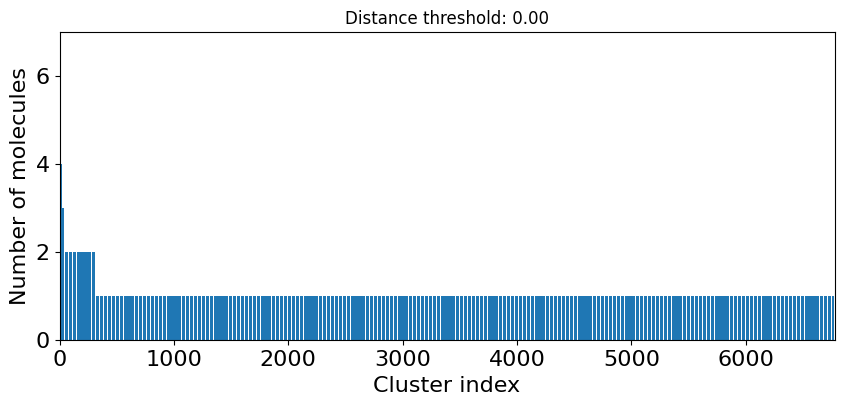

In [23]:
# Plot cluster size distribution
plot_cluster_sizes(clusters, dist_threshold)

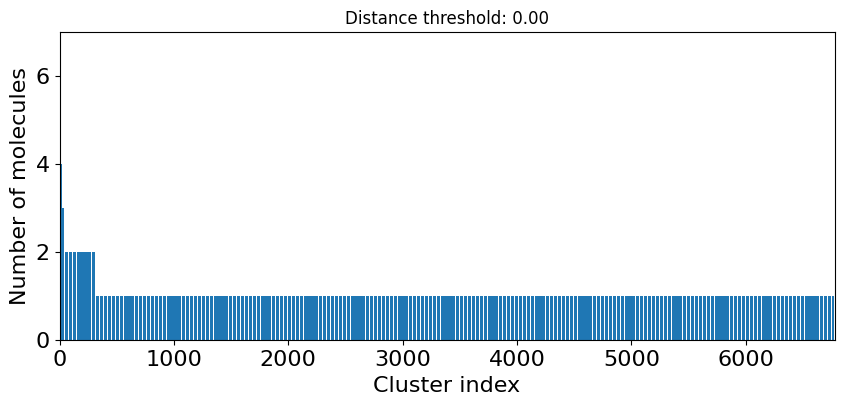

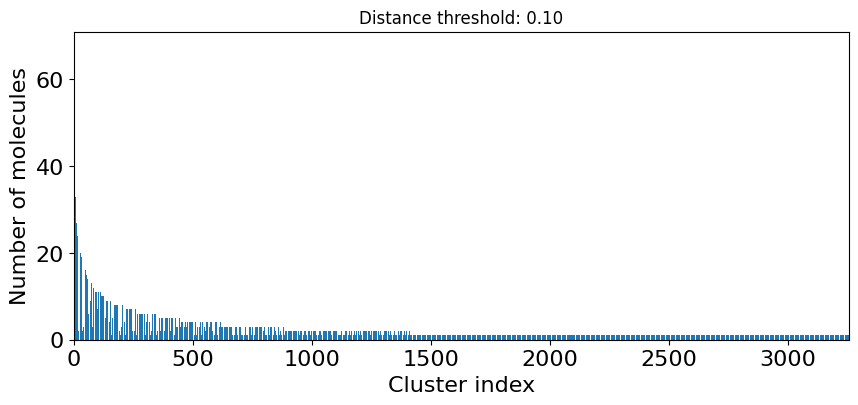

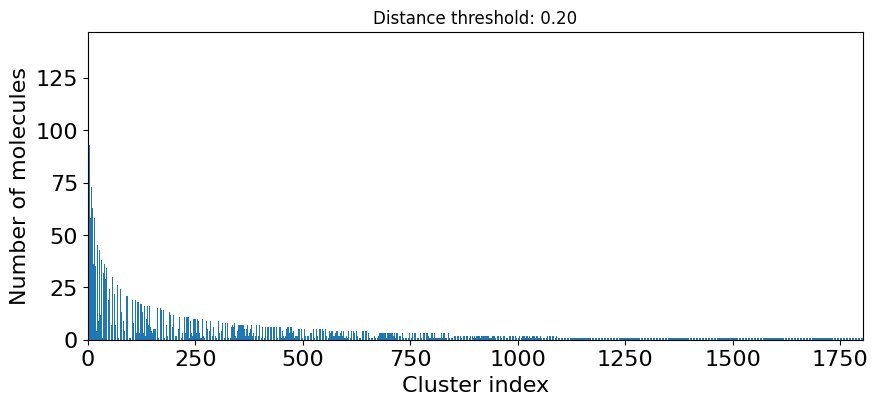

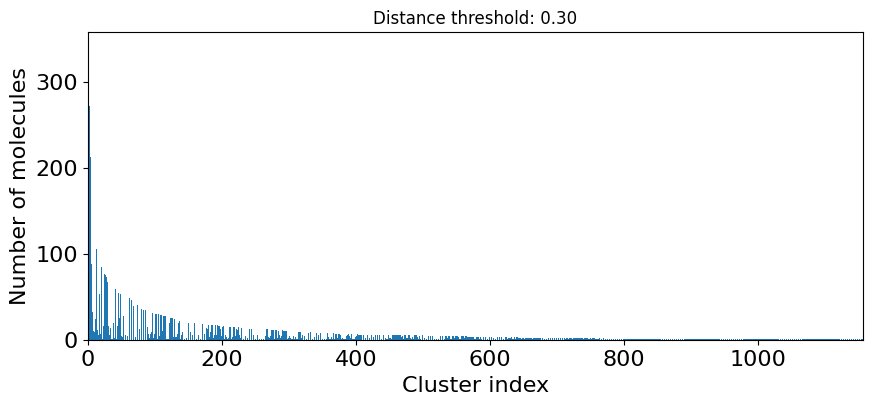

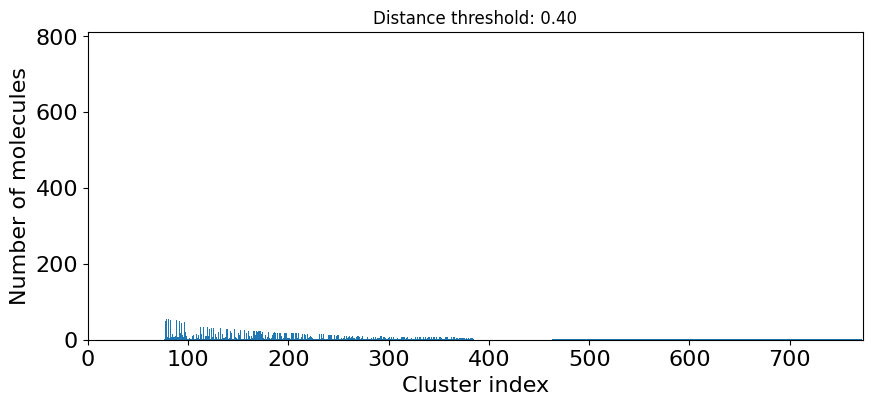

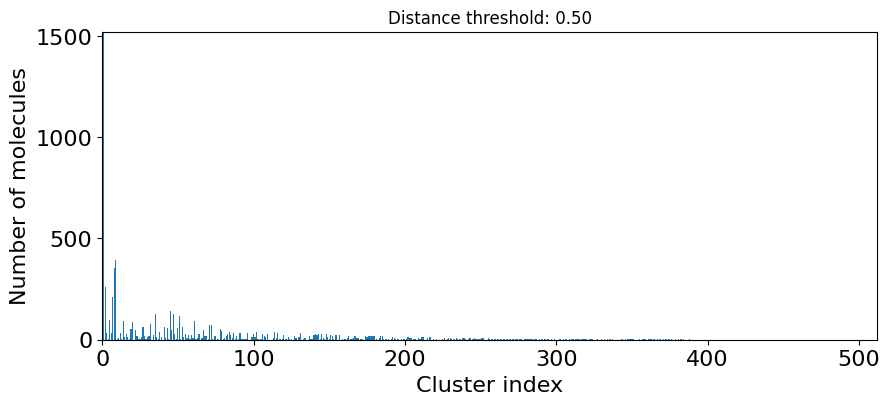

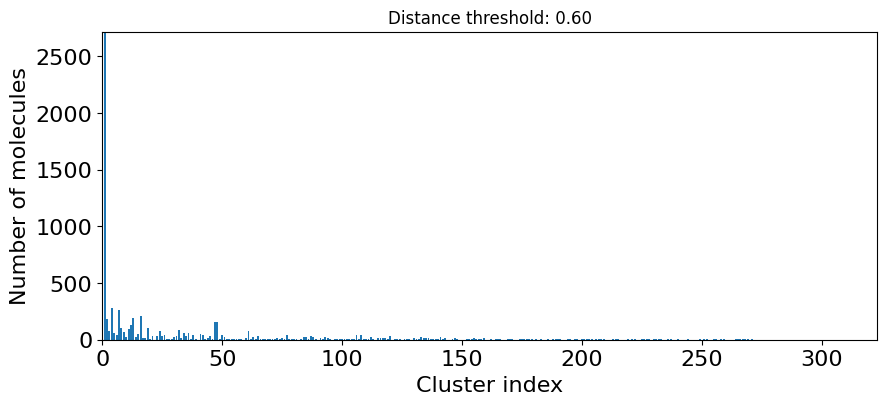

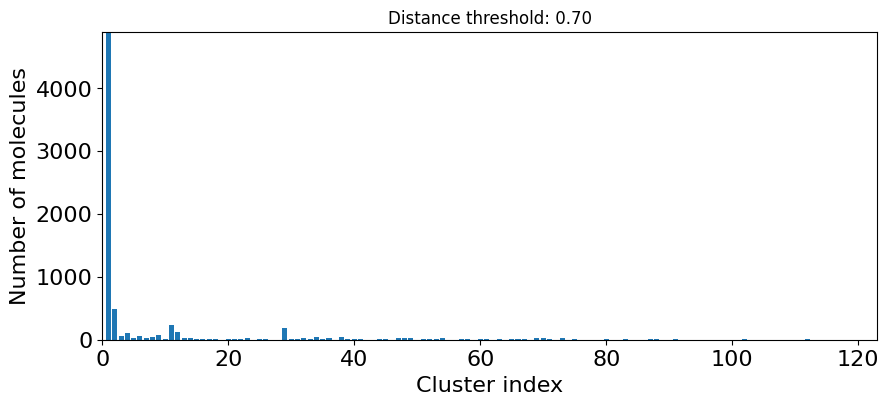

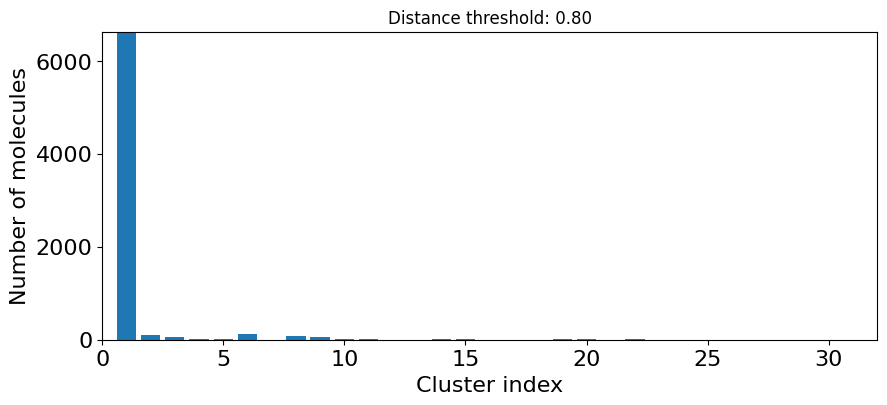

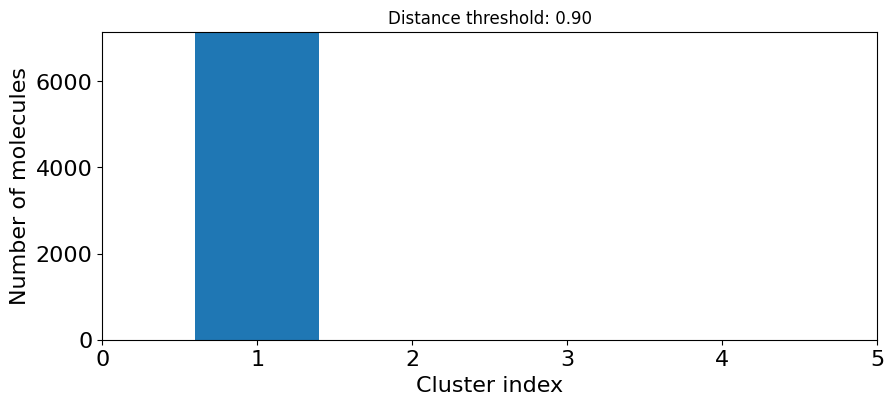

In [24]:
# Plot size distribution varying threshold from 0.0 to 1.1 with a step of 0.1
deb = 0.0
fin = 1.0
step = 0.1
for threshold in np.arange(start=deb, stop=fin, step=step):
    plot_cluster_sizes(cluster_fps(rdkit_fps_l, threshold), threshold)

## Cluster selection

In [25]:
# Select cluster corresponding to a distance threshold of 0.3
dist_threshold = 0.3
clusters = cluster_fps(rdkit_fps_l, dist_threshold)

In [26]:
# Number of clusters
print(f"Number of clusters: {len(clusters)}")

# Number of singletons (1 molecule in the cluster)
singletons_l = [c for c in clusters if len(c) == 1]
print(f"Number of singletons: {len(singletons_l)}")

# Number of molecules in the largest cluster
print(f"Number of molecules in the largest cluster: {len(clusters[0])}")

Number of clusters: 1157
Number of singletons: 554
Number of molecules in the largest cluster: 357


In [27]:
# Tanimoto similarity between the first 2 compounds of cluster #O
print(f"Intra Tanimoto similarity: {DataStructs.TanimotoSimilarity(rdkit_fps_l[clusters[0][0]], rdkit_fps_l[clusters[0][1]]):.2f}")

# Tanimoto similarity between the centroids of cluster #O and cluster #1
print(f"Inter Tanimoto similarity: {DataStructs.TanimotoSimilarity(rdkit_fps_l[clusters[0][0]], rdkit_fps_l[clusters[1][0]]):.2f}")

Intra Tanimoto similarity: 0.82
Inter Tanimoto similarity: 0.57


## Cluster visualisation

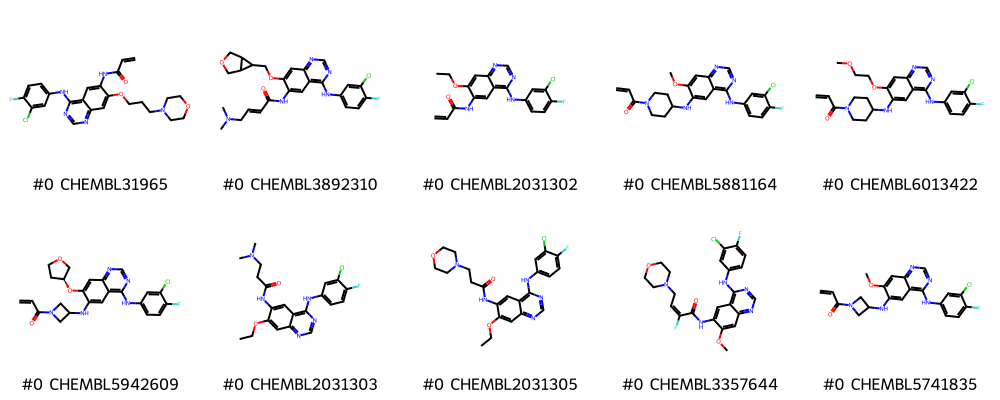

In [28]:
# Draw an image of the first 10 molecules from cluster #0, add their ChEMBL_ID on legend and the number of the cluster
n_cluster = 0
nb_mols = 10
Draw.MolsToGridImage(
    [compounds_l[ind][0] for ind in clusters[n_cluster][:nb_mols]],
    legends = [f"#{n_cluster} {compounds_l[ind][1]}" for ind in clusters[n_cluster][:nb_mols]],
    molsPerRow=5
)

In [29]:
# Save molecules from largest cluster (#0) in a sdf file
cluster0_sdf_path = str(DATA / "cluster0.sdf")
sdf = Chem.SDWriter(cluster0_sdf_path)
for index in clusters[0]:
    mol, label = compounds_l[index]
    # Set label as the property "_Name"
    mol.SetProp("_Name", label)
    # Write mol to the sdf file
    sdf.write(mol)
# Close the sdf file
sdf.close()

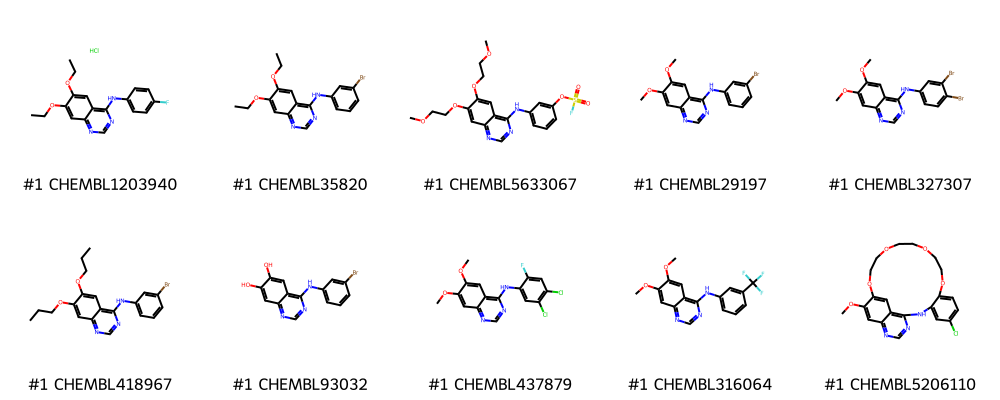

In [30]:
# Draw an image of the first 10 molecules from cluster #1, add their ChEMBL_ID on legend and the number of the cluster
n_cluster = 1
nb_mols = 10
Draw.MolsToGridImage(
    [compounds_l[ind][0] for ind in clusters[n_cluster][:nb_mols]],
    legends = [f"#{n_cluster} {compounds_l[ind][1]}" for ind in clusters[n_cluster][:nb_mols]],
    molsPerRow=5
)

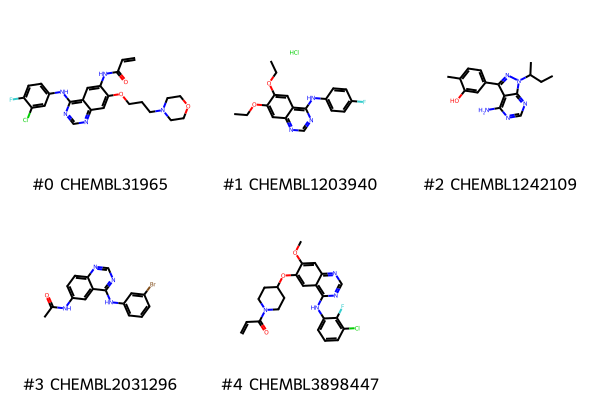

In [31]:
# Draw an image of the first 5 centroids, add their ChEMBL_ID on legend and the number of the cluster
nb_clusters = 5
Draw.MolsToGridImage(
    [compounds_l[clusters[ind][0]][0] for ind in range(0, nb_clusters)],
    legends = [f"#{ind} {compounds_l[clusters[ind][0]][1]}" for ind in range(0, nb_clusters)],
    molsPerRow=3
)

## Similarity within the first 10 clusters (intra-cluster similarity)

### Calculation

In [32]:
# Define a function to calculate Tanimoto similarity for all pairs of fingerprints in each cluster
def intra_tanimoto_similarity(fps_clusters):
    intra_similarity = list()
    # Calculate intra similarity per cluster
    for cluster in fps_clusters:
        intra_similarity.append([1 - x for x in tanimoto_distance_matrix(cluster)]) # convert distance similarity in Tanimoto similarity and append a list for each cluster
    return intra_similarity # list of list of Tanimoto similarity per cluster

In [33]:
# Recompute fingerprints for the first 10 selected clusters
fps_per_cluster = list()
for cluster in clusters[:10]:
    fps_per_cluster.append([rdkit_gen.GetFingerprint(compounds_l[ind][0]) for ind in cluster])

In [34]:
# Check fps_per_cluster
print(f"Type of fps_per_cluster: {type(fps_per_cluster)}")
print(f"Number of elements in fps_per_cluster : {len(fps_per_cluster)}")
print(f"Type of first element of fps_per_cluster: {type(fps_per_cluster[0])}")

Type of fps_per_cluster: <class 'list'>
Number of elements in fps_per_cluster : 10
Type of first element of fps_per_cluster: <class 'list'>


In [35]:
# Calculate intra-cluster tanimoto similarity
intra_tanimoto_sim = intra_tanimoto_similarity(fps_per_cluster)

In [36]:
# Check intra_tanimoto_sim
print(f"Type of intra_tanimoto_sim: {type(intra_tanimoto_sim)}")
print(f"Number of elements in intra_tanimoto_sim : {len(intra_tanimoto_sim)}")
print(f"Type of first element of intra_tanimoto_sim: {type(intra_tanimoto_sim[0])}")

Type of intra_tanimoto_sim: <class 'list'>
Number of elements in intra_tanimoto_sim : 10
Type of first element of intra_tanimoto_sim: <class 'list'>


### Visualisation

In [37]:
# Create a dataframe sim_df
# x column : similarity values
# y column : index of the corresponding cluster
sim_l = [] # list of dictionnaries {x,y}
for ind, cluster_sim in enumerate(intra_tanimoto_sim, start=1): # to associate the cluster index, starting from 1, to the similarity sub-list 
    for sim in cluster_sim:
        sim_l.append({"x":ind, "y":sim}) # fulfill the list of dictionnaries

sim_df = pd.DataFrame(sim_l)

In [38]:
# Check
print(f"sim_df.shape: {sim_df.shape}")
sim_df.head(2)

sim_df.shape: (174600, 2)


,x,y
0,1,0.821029
1,1,0.892583


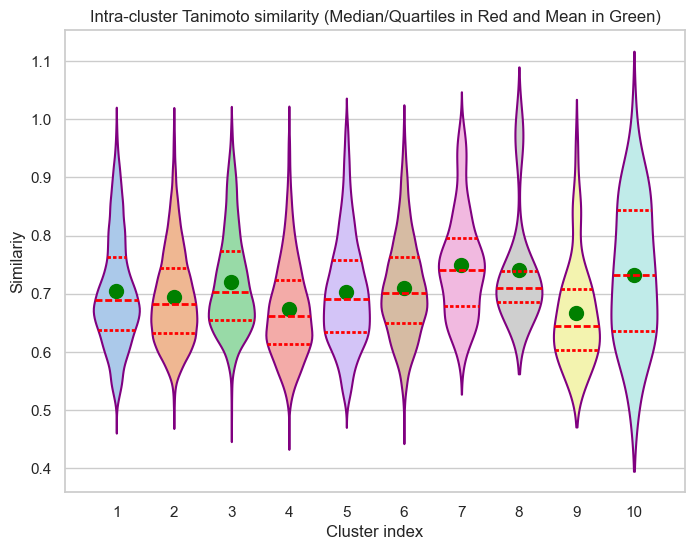

In [39]:
# Violin plot with seaborn (sns)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

ax = sns.violinplot(
    x="x", 
    y="y", 
    data=sim_df,
    inner="quartile",  # Show quartiles and median
    hue="x",           # Use 'hue' to avoid the warning
    palette="pastel",  # Color palette for violins
    legend=False,      # Disable redundant legend
    linewidth=1.5,     # Line thickness
)

# Customize the color of the lines (median and quartiles)
for line in ax.lines:
    line.set_color("red")      # Color of the lines (median and quartiles)
    line.set_linewidth(2)      # Line thickness

# Customize the border of the violins
for violin in ax.collections:
    violin.set_edgecolor("purple")  # Border color

# Manually add the mean
means = sim_df.groupby("x")["y"].mean()
for x, mean in means.items():
    plt.scatter(x=x-1, y=mean, color="green", s=100, label=f"Mean (x={x})")

# Set custom x-axis and y-axis labels
plt.xlabel("Cluster index")  # Replace with your desired x-axis label
plt.ylabel("Similariy")  # Replace with your desired y-axis label

plt.title("Intra-cluster Tanimoto similarity (Median/Quartiles in Red and Mean in Green)")
plt.show()

## Get the centroids compounds

In [40]:
# Get a centroid list (cluster centers: first compound in each cluster)
centroids_l = [compounds_l[c[0]] for c in clusters]

In [41]:
# Check
print(f"Number of centroids: {len(centroids_l)}")
print(f"Number of clusters: {len(clusters)}")

Number of centroids: 1157
Number of clusters: 1157


Remark

[A more complex selection is described in TOC.](https://github.com/volkamerlab/teachopencadd/blob/master/teachopencadd/talktorials/T005_compound_clustering/talktorial.ipynb)